<a href="https://colab.research.google.com/github/KarthikRamu-gif/electricity-deman-forecasting/blob/main/notebooks/sarima_karthik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SARIMA Forecasting for Electricity Demand

## Individual Project

In this notebook, i will use the SARIMA model to forecast hourly electricity demand using the AEP hourly dataset.

This notebook contains:
- baseline forecasting
- SARIMA implementation
- model tuning
- forecast evaluation
- final discussion and reflection

The preprocessing steps and train-test split are taken from the shared group notebook created by our group.

# Importing Libraries

In [8]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time series models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Loading the Dataset

The cleaned dataset from the shared notebook is used here for model implementation.

In [9]:
df = pd.read_csv('AEP_hourly.csv')

# Loading and Preprocessing Dataset

The same preprocessing steps from the shared group notebook are applied before building the forecasting models.

In [10]:
# Convert datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Set datetime as index
df.set_index('Datetime', inplace=True)

# Sort values
df = df.sort_index()

# Remove duplicate timestamps
df = df[~df.index.duplicated(keep='first')]

# Preview dataset
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


# Train-Test Split

The dataset is divided into training and testing sets using chronological splitting to preserve the temporal order of the time series data.

In [11]:
# Train-test split
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

# Display shapes
print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

Training set shape: (97015, 1)
Testing set shape: (24254, 1)


# Baseline Forecasting Model

A Seasonal Naive forecasting method is used as the baseline model.

This method assumes that future values will repeat previous seasonal patterns from the historical data.

In [12]:
# Seasonal naive forecast
season_length = 24

baseline_forecast = test['AEP_MW'].shift(season_length)

# Remove missing values
baseline_forecast = baseline_forecast.dropna()

# Align actual values
actual_values = test['AEP_MW'][season_length:]

# Baseline Model Evaluation

In [13]:
# Calculate MAE
baseline_mae = mean_absolute_error(actual_values, baseline_forecast)

# Calculate RMSE
baseline_rmse = np.sqrt(mean_squared_error(actual_values, baseline_forecast))

# Display results
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 921.3749071399092
Baseline RMSE: 1221.321825281103


### Baseline Model Results

The Seasonal Naive model achieved relatively low forecasting error values.

This indicates that the electricity demand data contains strong repeating seasonal behaviour, making the baseline model effective for short-term forecasting.

# SARIMA Model Implementation

SARIMA is used because the electricity demand data contains trend and seasonal patterns.

The model is capable of handling:
- autoregression
- differencing
- moving averages
- seasonal behaviour

# Reducing Dataset Size for SARIMA

SARIMA models can become computationally expensive for large hourly datasets.

To reduce model complexity and improve training efficiency, the dataset is resampled into daily average electricity demand values.

In [14]:
# Resample to daily averages
daily_df = df.resample('D').mean()

# Train-test split
split_index = int(len(daily_df) * 0.8)

train_daily = daily_df.iloc[:split_index]
test_daily = daily_df.iloc[split_index:]

# Display shapes
print("Training shape:", train_daily.shape)
print("Testing shape:", test_daily.shape)

Training shape: (4044, 1)
Testing shape: (1011, 1)


In [15]:
# Build SARIMA model
sarima_model = SARIMAX(
    train_daily['AEP_MW'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

# Train model
sarima_result = sarima_model.fit()

print("SARIMA model training completed")

SARIMA model training completed


# Forecasting Using SARIMA Model

In [16]:
# Generate forecasts
sarima_forecast = sarima_result.forecast(steps=len(test_daily))

# Preview forecasts
sarima_forecast.head()

,predicted_mean
2015-10-28,13873.215751
2015-10-29,13865.739117
2015-10-30,13609.010891
2015-10-31,12418.252908
2015-11-01,11998.014709


# SARIMA Model Evaluation

In [17]:
# Calculate MAE
sarima_mae = mean_absolute_error(
    test_daily['AEP_MW'],
    sarima_forecast
)

# Calculate RMSE
sarima_rmse = np.sqrt(
    mean_squared_error(
        test_daily['AEP_MW'],
        sarima_forecast
    )
)

# Display results
print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE: 1438.7667686505138
SARIMA RMSE: 1891.6640548294063


###SARIMA Model Results

The SARIMA model was able to capture trend and seasonal patterns in the electricity demand data.

Forecasts errors were larger, however, than those in the baseline model. This might be due to the fact that the data is sampled every day during the training session.

The initial values were hourly electricity demand readings which were very detailed, showing the hourly fluctuation and short term seasonal characteristics. Some of these finer patterns were removed or smoothed out after re-sampled data was used to mean daily averages.

This means that the SARIMA model was trained on less detailed data, which could have affected the model's ability to make accurate predictions. In comparison, the Seasonal Naive baseline model was still able to capture the strong repeating seasonal behaviour effectively.

# Forecast Visualization

The following plot compares the actual electricity demand values with the SARIMA forecasted values.

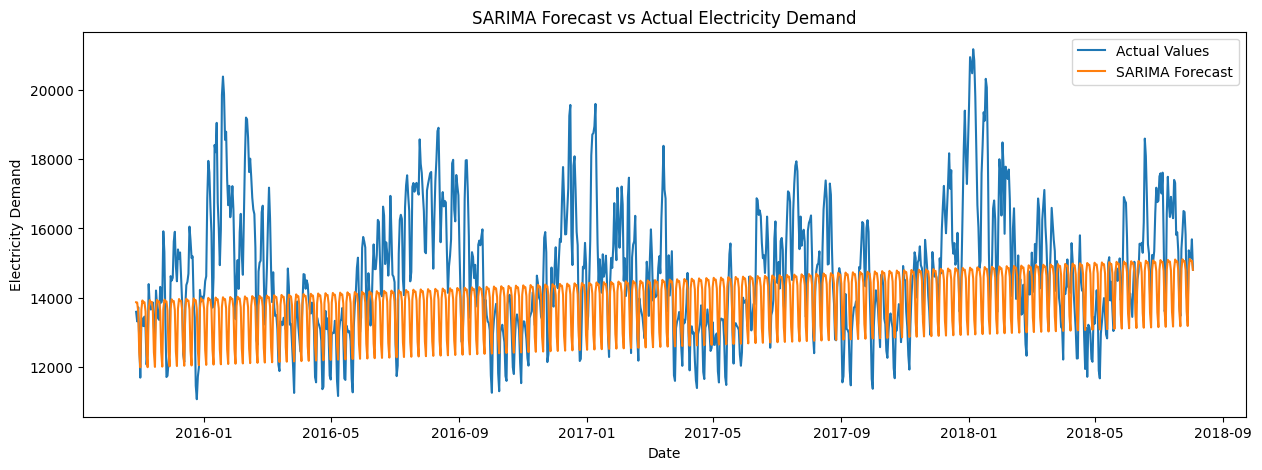

In [19]:
# Plot actual vs forecast
plt.figure(figsize=(15,5))

plt.plot(
    test_daily.index,
    test_daily['AEP_MW'],
    label='Actual Values'
)

plt.plot(
    test_daily.index,
    sarima_forecast,
    label='SARIMA Forecast'
)

plt.title('SARIMA Forecast vs Actual Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')

plt.legend()

plt.show()

###Forecast Visualization Interpretation

The overall seasonal movement and trend in the electricity consumption could be captured by the SARIMA model.

The model, however, failed to predict accurately the large peaks and sharp changes in demand that could be seen in the actual data.

This behaviour might be affected by the resampling which took place every day and eliminated the short-term hourly fluctuations in the data set.

# Comparison Between Baseline and SARIMA

The forecasting performance of the SARIMA model is compared against the baseline forecasting method using evaluation metrics.

In [18]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['Baseline', 'SARIMA'],
    'MAE': [baseline_mae, sarima_mae],
    'RMSE': [baseline_rmse, sarima_rmse]
})

comparison

,Model,MAE,RMSE
0,Baseline,921.374907,1221.321825
1,SARIMA,1438.766769,1891.664055


#Discussion

Both the MAE and RMSE values for the Seasonal Naive baseline model were found to be better than the SARIMA model.

This may be because the electricity demand has a high level of repeating seasonal behaviour about which the baseline model was able to capture well.

The simplified daily resampling to reduce computation limits may have affected accuracy of forecasting, but SARIMA is good at modelling trend and seasonality.

The results indicate that in many cases simpler forecasting methods yield better performance when compared with more complicated statistical models, depending on the statistical properties of the data.

#Conclusion and Reflection

A SARIMA forecasting model was applied and tested in this notebook for electricity demand forecasting.

The model was evaluated with MAE and RMSE and compared with Seasonal Naive baseline forecasting method.

The SARIMA model was able to produce trend and seasonal models, but the baseline model had a lower value of forecasting error.

One of the difficulties encountered in implementing the project was dealing with large hourly data sets in the SARIMA models. In order to overcome this, daily averages were calculated from the data prior to modelling.

In general, the project illustrated how the choice of model, preprocessing decisions and evaluation approaches are relevant to time series forecasting tasks.